:Student Name = Arshad Ali
Intern ID = ARCH-2610-0747
Subject: Data Science Intership and Training Program
Task 2 = Stock Price Predication

/tmp/ipython-input-2583842852.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0377
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0016
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0012
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0012
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 9.0573e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 8.2887e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 8.3253e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0010
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 7.9402e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 6.0165e-04
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 6.9844e-04
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.0888e-04
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.2704e-04
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 5.7207e-04
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━

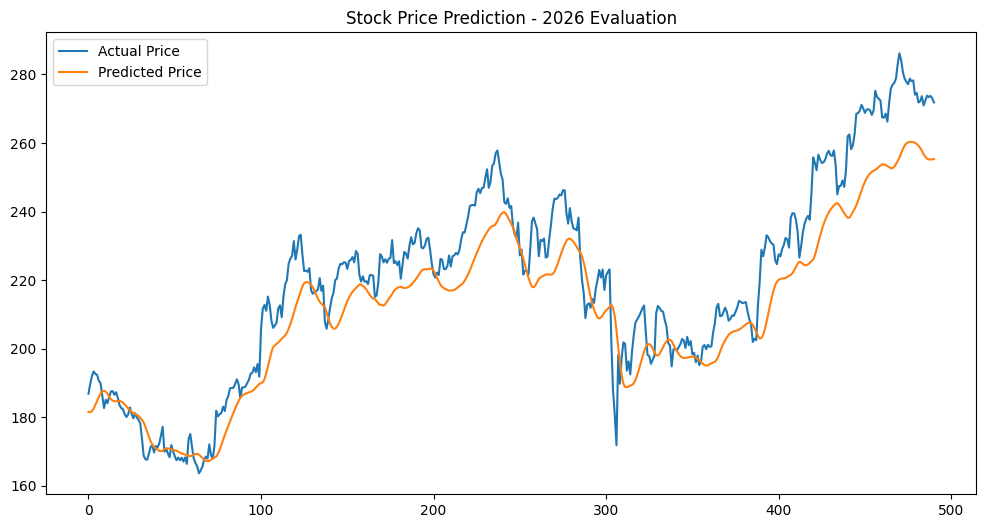

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- Step 1: Preprocess the Data ---
def load_and_preprocess(ticker, start="2016-01-01", end="2026-01-01"):
    # Download data from Yahoo Finance
    df = yf.download(ticker, start=start, end=end)

    # Feature selection: Open, High, Low, Close, Volume
    data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values

    # Normalize features to [0, 1] range for stable training
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    return scaled_data, scaler, df

scaled_data, scaler, original_df = load_and_preprocess("AAPL")

# Create sequences (e.g., use past 60 days to predict the next day)
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 3]) # Predicting 'Close' price (index 3)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Split into 80% training and 20% testing
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Step 2: Choose and Train the Model (LSTM) ---
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1) # Output: Predicted Closing Price
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=1)

# --- Step 3: Evaluate Prediction Accuracy ---
predictions = model.predict(X_test)

# Inverse transform to get actual price values
# (Requires creating a dummy array to match scaler shape)
dummy = np.zeros((len(predictions), 5))
dummy[:, 3] = predictions.flatten()
predictions_actual = scaler.inverse_transform(dummy)[:, 3]

dummy_y = np.zeros((len(y_test), 5))
dummy_y[:, 3] = y_test
y_test_actual = scaler.inverse_transform(dummy_y)[:, 3]

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(np.mean((predictions_actual - y_test_actual)**2))
print(f"Model Accuracy (RMSE): {rmse:.2f}")

# Visualize Results
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions_actual, label="Predicted Price")
plt.title("Stock Price Prediction - 2026 Evaluation")
plt.legend()
plt.show()